In [1]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


2024-08-17 10:27:46.872914: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-17 10:27:46.883730: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-17 10:27:46.886958: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-17 10:27:46.895687: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-17 10:27:47.483858: W tensorflow/compiler/tf2

Num GPUs Available:  1


I0000 00:00:1723868867.997090   50767 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1723868868.027641   50767 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1723868868.028085   50767 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


ModuleNotFoundError: No module named 'torch'

In [9]:
!pip install networkx


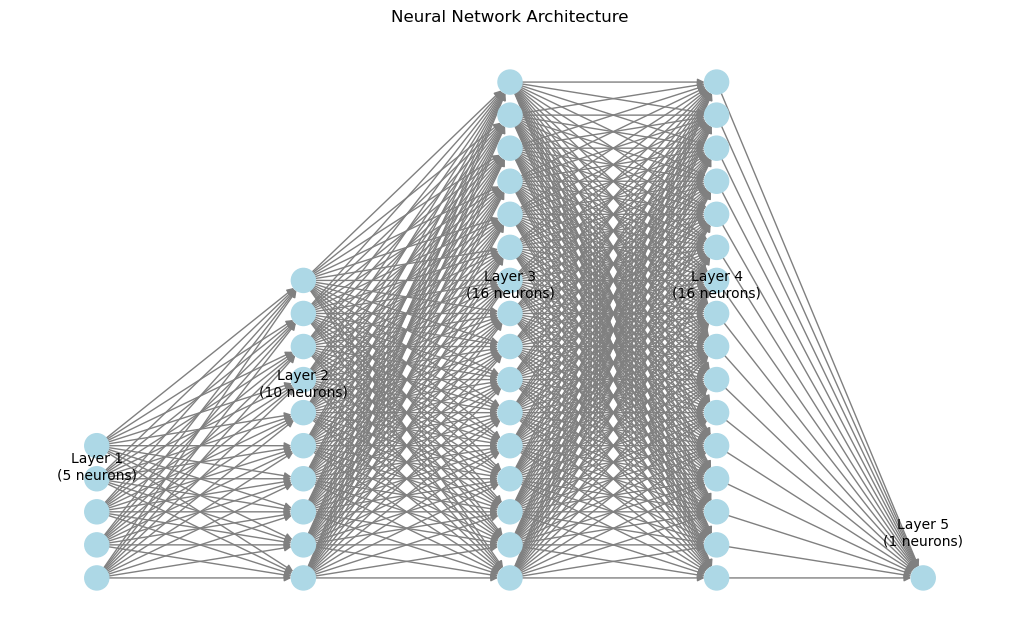

In [10]:
import matplotlib.pyplot as plt
import networkx as nx

def draw_neural_network(layers):
    G = nx.DiGraph()
    pos = {}
    node_sizes = []
    
    layer_distances = 1
    layer_nodes_distances = 1
    
    # Add nodes and edges
    for layer_idx, layer in enumerate(layers):
        for neuron_idx in range(layer):
            node_name = f"L{layer_idx}N{neuron_idx}"
            G.add_node(node_name)
            pos[node_name] = (layer_idx * layer_distances, neuron_idx * layer_nodes_distances)
            node_sizes.append(300)
            if layer_idx > 0:
                for prev_neuron_idx in range(layers[layer_idx - 1]):
                    prev_node_name = f"L{layer_idx - 1}N{prev_neuron_idx}"
                    G.add_edge(prev_node_name, node_name)
    
    # Draw the network
    plt.figure(figsize=(10, 6))
    nx.draw(G, pos, with_labels=False, node_size=node_sizes, node_color='lightblue', edge_color='gray')
    
    # Add labels for layers
    for layer_idx, layer in enumerate(layers):
        x = layer_idx * layer_distances
        y = (layer - 1) * layer_nodes_distances / 2
        plt.text(x, y + 1, f"Layer {layer_idx + 1}\n({layer} neurons)", horizontalalignment='center')
    
    plt.title("Neural Network Architecture")
    plt.show()

# Define the model layers
layers = [5, 10, 16, 16, 1]  # input layer with 5 features, and subsequent hidden/output layers

# Draw the neural network
draw_neural_network(layers)


In [11]:
import matplotlib.pyplot as plt
import networkx as nx
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError as MSE
from tensorflow.keras.metrics import MeanAbsoluteError as MAE

def draw_neural_network(model):
    # Extract the input shape for each layer using get_input_shape_at(0)
    layers = [layer.get_input_shape_at(0)[-1] for layer in model.layers]
    layers.append(model.layers[-1].units)  # Add the units of the last layer (output layer)
    
    G = nx.DiGraph()
    pos = {}
    node_sizes = []

    layer_distances = 1
    layer_nodes_distances = 1

    # Add nodes and edges
    for layer_idx, layer in enumerate(layers):
        for neuron_idx in range(layer):
            node_name = f"L{layer_idx}N{neuron_idx}"
            G.add_node(node_name)
            pos[node_name] = (layer_idx * layer_distances, neuron_idx * layer_nodes_distances)
            node_sizes.append(300)
            if layer_idx > 0:
                for prev_neuron_idx in range(layers[layer_idx - 1]):
                    prev_node_name = f"L{layer_idx - 1}N{prev_neuron_idx}"
                    G.add_edge(prev_node_name, node_name)

    # Draw the network
    plt.figure(figsize=(10, 6))
    nx.draw(G, pos, with_labels=False, node_size=node_sizes, node_color='lightblue', edge_color='gray')

    # Add labels for layers
    for layer_idx, layer in enumerate(layers):
        x = layer_idx * layer_distances
        y = (layer - 1) * layer_nodes_distances / 2
        plt.text(x, y + 1, f"Layer {layer_idx + 1}\n({layer} neurons)", horizontalalignment='center')

    plt.title("Neural Network Architecture")
    plt.show()

# Define the model
model = Sequential([
    Dense(units=10, input_shape=(5,), activation='relu'),
    Dense(units=16, activation='relu'),
    Dense(units=16, activation='relu'),
    Dense(units=1, activation='relu'),
])

model.compile(optimizer=Adam(learning_rate=0.0001), loss=MSE(), metrics=[MAE()])

# Draw the neural network
draw_neural_network(model)


AttributeError: 'Dense' object has no attribute 'get_input_shape_at'